## Data Exploration & Dataset Overview

#### PADS (Parkinson's Disease Smartwatch) Dataset

## 1. Setup: Libraries and Paths

The dataset contains three main components:
- **patients/**: Demographic and clinical data (patient_001.json ... patient_469.json)
- **movement/**: Smartwatch sensor data (observation_001.json ... observation_469.json)
- **questionnaire/**: Clinical questionnaires
- **timeseries/**: Time-series accelerometer and gyroscope data (referenced in observations)

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Define paths
BASE_PATH = Path('../..') / 'data' / 'raw' / 'pads-parkinsons-disease-smartwatch-dataset-1.0.0'
PATIENTS_PATH = BASE_PATH / 'patients'
OBSERVATIONS_PATH = BASE_PATH / 'movement'
QUESTIONNAIRE_PATH = BASE_PATH / 'questionnaire'

print(f"Base folder: {BASE_PATH}")
print(f"Patients folder exists: {PATIENTS_PATH.exists()}")
print(f"Observations folder exists: {OBSERVATIONS_PATH.exists()}")
print(f"Questionnaire folder exists: {QUESTIONNAIRE_PATH.exists()}")

Base folder: ..\..\data\raw\pads-parkinsons-disease-smartwatch-dataset-1.0.0
Patients folder exists: True
Observations folder exists: True
Questionnaire folder exists: True


In [2]:
# List available files
patients_files = sorted(list(PATIENTS_PATH.glob('*.json')))
observations_files = sorted(list(OBSERVATIONS_PATH.glob('observation_*.json')))
questionnaire_files = sorted(list(QUESTIONNAIRE_PATH.glob('*.json'))) if QUESTIONNAIRE_PATH.exists() else []

print(f"Number of patient files: {len(patients_files)}")
print(f"Number of observation files: {len(observations_files)}")
print(f"Number of questionnaire files: {len(questionnaire_files)}")
print(f"\nFirst 5 patient files: {[f.name for f in patients_files[:5]]}")
print(f"First 5 observation files: {[f.name for f in observations_files[:5]]}")

Number of patient files: 469
Number of observation files: 469
Number of questionnaire files: 469

First 5 patient files: ['patient_001.json', 'patient_002.json', 'patient_003.json', 'patient_004.json', 'patient_005.json']
First 5 observation files: ['observation_001.json', 'observation_002.json', 'observation_003.json', 'observation_004.json', 'observation_005.json']


## 2. Load Patient Demographic Data

In [3]:
def load_json_files(file_list):
    """Load multiple JSON files into a list of dictionaries."""
    data = []
    for file_path in file_list:
        try:
            with open(file_path, 'r') as f:
                data.append(json.load(f))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    return data

# Load patient data
print("Loading patient data...")
patients_data = load_json_files(patients_files)
df_patients = pd.DataFrame(patients_data)
print(f"✓ Loaded {len(df_patients)} patient records")
print(f"\nDataFrame shape: {df_patients.shape}")
print(f"Columns: {list(df_patients.columns)}")

Loading patient data...
✓ Loaded 469 patient records

DataFrame shape: (469, 14)
Columns: ['resource_type', 'id', 'study_id', 'condition', 'disease_comment', 'age_at_diagnosis', 'age', 'height', 'weight', 'gender', 'handedness', 'appearance_in_kinship', 'appearance_in_first_grade_kinship', 'effect_of_alcohol_on_tremor']


## 3. Dataset Composition - Patient Data Overview

In [4]:
# Data types and info
print("=" * 70)
print("PATIENT DATA - INFO")
print("=" * 70)
df_patients.info()
print(f"\nMemory usage: {df_patients.memory_usage(deep=True).sum() / 1024:.2f} KB")

PATIENT DATA - INFO
<class 'pandas.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   resource_type                      469 non-null    str   
 1   id                                 469 non-null    str   
 2   study_id                           469 non-null    str   
 3   condition                          469 non-null    str   
 4   disease_comment                    469 non-null    str   
 5   age_at_diagnosis                   469 non-null    int64 
 6   age                                469 non-null    int64 
 7   height                             469 non-null    int64 
 8   weight                             469 non-null    int64 
 9   gender                             469 non-null    str   
 10  handedness                         469 non-null    str   
 11  appearance_in_kinship              469 non-null    bool  
 12 

In [5]:
# Display first and last rows
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)
print(df_patients.head())


FIRST 5 ROWS
  resource_type   id study_id                 condition  \
0       patient  001     PADS                   Healthy   
1       patient  002     PADS  Other Movement Disorders   
2       patient  003     PADS                   Healthy   
3       patient  004     PADS               Parkinson's   
4       patient  005     PADS               Parkinson's   

                 disease_comment  age_at_diagnosis  age  height  weight  \
0                              -                56   56     173      78   
1  Left-Sided resting tremor ...                69   81     193     104   
2                              -                45   45     170      78   
3        IPS akinetic-rigid type                63   67     161      90   
4        IPS tremordominant type                65   75     172      86   

   gender handedness  appearance_in_kinship appearance_in_first_grade_kinship  \
0    male      right                   True                           True      
1    male      rig

## 4. Initial Data Quality Checks

In [6]:
# Missing values
print("=" * 70)
print("MISSING VALUES")
print("=" * 70)
missing_data = df_patients.isnull().sum()
missing_percentage = (missing_data / len(df_patients)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Percentage': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("✓ No missing values found!")

MISSING VALUES
                           Column  Missing_Count  Percentage
appearance_in_first_grade_kinship            288   61.407249


In [7]:
# Duplicates
print("\n" + "=" * 70)
print("DUPLICATES")
print("=" * 70)
duplicates = df_patients.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("Duplicate rows:")
    print(df_patients[df_patients.duplicated(keep=False)].sort_values('id'))


DUPLICATES
Number of duplicate rows: 0


## 5. Descriptive Statistics - Overview

In [8]:
# Numerical statistics
print("=" * 70)
print("DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS")
print("=" * 70)
print(df_patients.describe())

DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS
       age_at_diagnosis         age      height      weight
count        469.000000  469.000000  469.000000  469.000000
mean          55.275053   64.240938  174.181237   81.899787
std           17.105225   10.698847   10.921397   17.916252
min            0.000000   40.000000   55.000000   45.000000
25%           48.000000   56.000000  168.000000   69.000000
50%           58.000000   65.000000  175.000000   81.000000
75%           67.000000   72.000000  181.000000   92.000000
max           90.000000   90.000000  203.000000  181.000000


## 6. Target Distribution: PD vs Healthy

In [9]:
print("=" * 70)
print("TARGET DISTRIBUTION - CONDITION")
print("=" * 70)
condition_dist = df_patients['condition'].value_counts()
condition_pct = (condition_dist / len(df_patients)) * 100
dist_df = pd.DataFrame({
    'Condition': condition_dist.index,
    'Count': condition_dist.values,
    'Percentage': condition_pct.values
})
print(dist_df.to_string(index=False))
print(f"\nTotal samples: {len(df_patients)}")

TARGET DISTRIBUTION - CONDITION
               Condition  Count  Percentage
             Parkinson's    276   58.848614
                 Healthy     79   16.844350
Other Movement Disorders     60   12.793177
        Essential Tremor     28    5.970149
   Atypical Parkinsonism     15    3.198294
      Multiple Sclerosis     11    2.345416

Total samples: 469


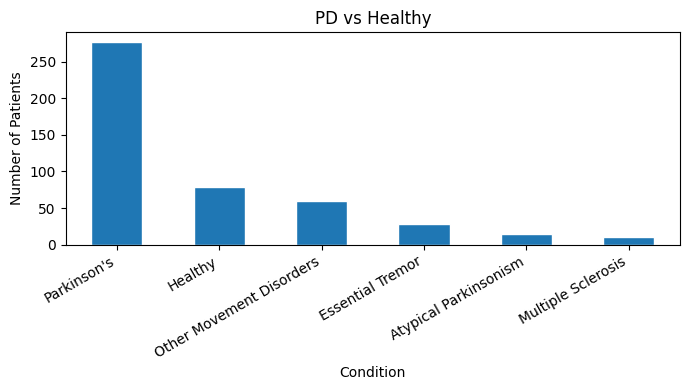

In [53]:
condition_dist.plot(kind='bar', edgecolor='white')

plt.title('PD vs Healthy')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(Path('../..') / 'results' / 'figures' / 'pd_vs_healthy_barplot.png', dpi=180, bbox_inches='tight')
plt.show()

## 7 Demographics: Age & Gender Analysis

DEMOGRAPHIC VISUALIZATIONS


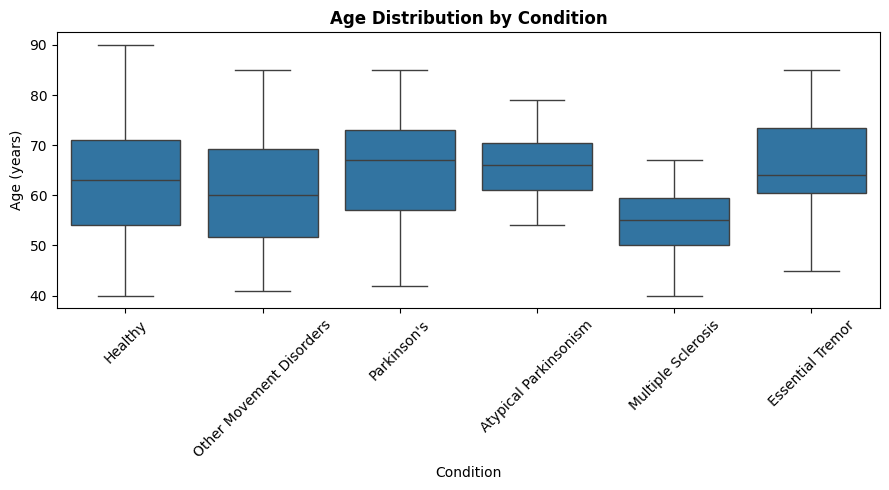

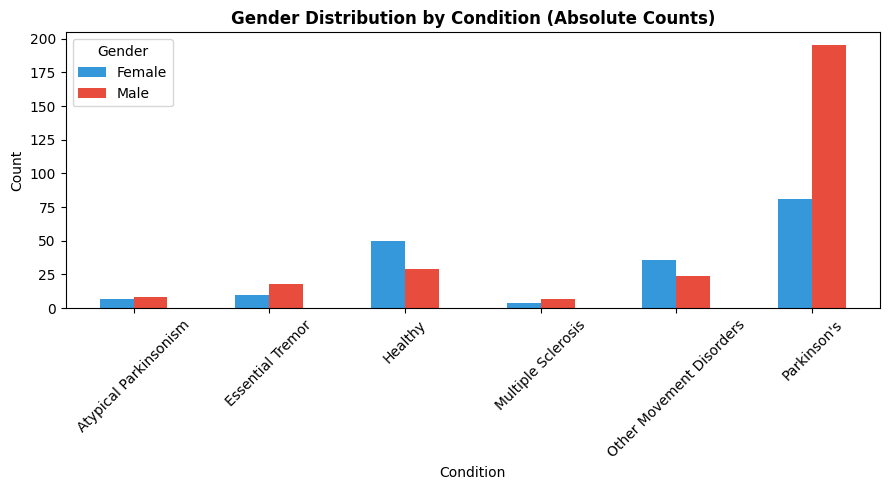


WEIGHT ANALYSIS


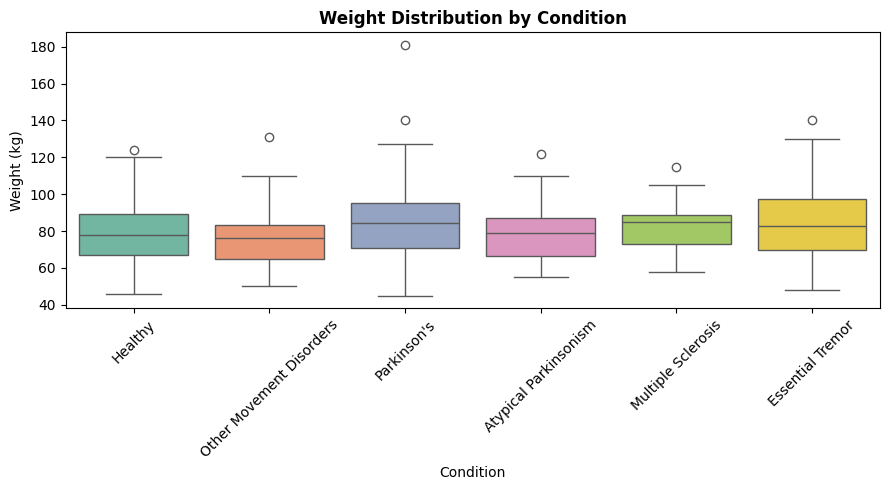

In [58]:
print("=" * 70)
print("DEMOGRAPHIC VISUALIZATIONS")
print("=" * 70)

figures_dir = Path('../..') / 'results' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# 1. Age distribution by condition (boxplot)
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=df_patients, x='condition', y='age', ax=ax)
ax.set_title('Age Distribution by Condition', fontsize=12, fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('Age (years)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(figures_dir / 'age_distribution_by_condition.png', dpi=180, bbox_inches='tight')
plt.show()

# 2. Gender distribution by condition (absolute counts)
gender_counts = pd.crosstab(df_patients['condition'], df_patients['gender'])

fig, ax = plt.subplots(figsize=(9, 5))

gender_counts.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title('Gender Distribution by Condition (Absolute Counts)', fontsize=12, fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('Count')
ax.legend(title='Gender', labels=['Female', 'Male'])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(figures_dir / 'gender_distribution_by_condition.png', dpi=180, bbox_inches='tight')
plt.show()

# 3. Weight analysis
print("\n" + "=" * 70)
print("WEIGHT ANALYSIS")
print("=" * 70)

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=df_patients, x='condition', y='weight', ax=ax, palette='Set2')
ax.set_title('Weight Distribution by Condition', fontsize=12, fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('Weight (kg)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(figures_dir / 'weight_by_condition.png', dpi=180, bbox_inches='tight')
plt.show()

In [52]:
print("=" * 70)
print("STATISTICAL TESTS: DEMOGRAPHIC VARIABLES SIGNIFICANCE")
print("=" * 70)

# 1. ANOVA test for Age
print("\n[1] AGE - ONE-WAY ANOVA Test")
print("-" * 70)

groups_age = []
for condition in sorted(df_patients['condition'].unique()):
    values = df_patients[df_patients['condition'] == condition]['age'].dropna().values
    if len(values) > 1:
        groups_age.append(values)

if len(groups_age) >= 2:
    f_stat, p_val = f_oneway(*groups_age)
    is_significant = "✓ SIGNIFICANT" if p_val < 0.05 else "✗ Not significant"
    print(f"F-statistic: {f_stat:.3f}")
    print(f"p-value: {p_val:.6f}")
    print(f"Result: {is_significant}")

# 2. ANOVA test for Height
print("\n[2] HEIGHT - ONE-WAY ANOVA Test")
print("-" * 70)

groups_height = []
for condition in sorted(df_patients['condition'].unique()):
    values = df_patients[df_patients['condition'] == condition]['height'].dropna().values
    if len(values) > 1:
        groups_height.append(values)

if len(groups_height) >= 2:
    f_stat, p_val = f_oneway(*groups_height)
    is_significant = "✓ SIGNIFICANT" if p_val < 0.05 else "✗ Not significant"
    print(f"F-statistic: {f_stat:.3f}")
    print(f"p-value: {p_val:.6f}")
    print(f"Result: {is_significant}")

# 3. ANOVA test for Weight
print("\n[3] WEIGHT - ONE-WAY ANOVA Test")
print("-" * 70)

groups_weight = []
for condition in sorted(df_patients['condition'].unique()):
    values = df_patients[df_patients['condition'] == condition]['weight'].dropna().values
    if len(values) > 1:
        groups_weight.append(values)

if len(groups_weight) >= 2:
    f_stat, p_val = f_oneway(*groups_weight)
    is_significant = "✓ SIGNIFICANT" if p_val < 0.05 else "✗ Not significant"
    print(f"F-statistic: {f_stat:.3f}")
    print(f"p-value: {p_val:.6f}")
    print(f"Result: {is_significant}")

# 4. Chi-square test for Gender distribution
print("\n[4] GENDER - CHI-SQUARE Test")
print("-" * 70)

contingency_table = pd.crosstab(df_patients['condition'], df_patients['gender'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p_val:.6f}")
print(f"Degrees of freedom: {dof}")
is_significant = "✓ SIGNIFICANT (VERY STRONG!)" if p_val < 0.05 else "✗ Not significant"
print(f"Result: {is_significant}")

STATISTICAL TESTS: DEMOGRAPHIC VARIABLES SIGNIFICANCE

[1] AGE - ONE-WAY ANOVA Test
----------------------------------------------------------------------
F-statistic: 4.106
p-value: 0.001170
Result: ✓ SIGNIFICANT

[2] HEIGHT - ONE-WAY ANOVA Test
----------------------------------------------------------------------
F-statistic: 4.346
p-value: 0.000709
Result: ✓ SIGNIFICANT

[3] WEIGHT - ONE-WAY ANOVA Test
----------------------------------------------------------------------
F-statistic: 2.439
p-value: 0.033740
Result: ✓ SIGNIFICANT

[4] GENDER - CHI-SQUARE Test
----------------------------------------------------------------------
Chi-square statistic: 41.427
p-value: 0.000000
Degrees of freedom: 5
Result: ✓ SIGNIFICANT (VERY STRONG!)


## 8. Load Observation/Movement Data

Now let's explore the smartwatch sensor data structure.

In [11]:
print("Loading observation data...")
observations_data = load_json_files(observations_files)
print(f"✓ Loaded {len(observations_data)} observation records")

# Create a flattened DataFrame with key metadata
obs_metadata = []
for obs in observations_data:
    obs_metadata.append({
        'subject_id': obs.get('subject_id'),
        'study_id': obs.get('study_id'),
        'device_id': obs.get('device_id'),
        'id': obs.get('id'),
        'sampling_rate': obs.get('sampling_rate'),
        'data_type': obs.get('data_type'),
        'num_sessions': len(obs.get('session', []))
    })

df_observations = pd.DataFrame(obs_metadata)
print(f"\nObservations DataFrame shape: {df_observations.shape}")
print(f"Columns: {list(df_observations.columns)}")

Loading observation data...
✓ Loaded 469 observation records

Observations DataFrame shape: (469, 7)
Columns: ['subject_id', 'study_id', 'device_id', 'id', 'sampling_rate', 'data_type', 'num_sessions']


In [12]:
print("=" * 70)
print("OBSERVATION DATA - OVERVIEW")
print("=" * 70)
print(df_observations.head())

OBSERVATION DATA - OVERVIEW
  subject_id study_id             device_id                       id  \
0        001     PADS  Apple Watch Series 4  Neurological Assessment   
1        002     PADS  Apple Watch Series 3  Neurological Assessment   
2        003     PADS  Apple Watch Series 4  Neurological Assessment   
3        004     PADS  Apple Watch Series 3  Neurological Assessment   
4        005     PADS  Apple Watch Series 4  Neurological Assessment   

   sampling_rate data_type  num_sessions  
0            100     float            11  
1            100     float            11  
2            100     float            11  
3            100     float            11  
4            100     float            11  


## 8.1 Session-Level Exploration (Movement)

In [27]:
session_rows = []
for obs in observations_data:
    for session in obs.get('session', []):
        for record in session.get('records', []):
            session_rows.append({
                'subject_id': obs.get('subject_id'),
                'record_name': session.get('record_name'),
                'rows_expected': session.get('rows'),
                'device_location': record.get('device_location'),
                'file_name': record.get('file_name'),
                'n_channels': len(record.get('channels', []))
            })

df_sessions = pd.DataFrame(session_rows)

print('=' * 70)
print('SESSION-LEVEL OVERVIEW')
print('=' * 70)
print(f'Session-record rows: {len(df_sessions)}')
print(f'Unique tasks (record_name): {df_sessions["record_name"].nunique()}')
print(f'Unique subjects: {df_sessions["subject_id"].nunique()}')
print('\nTop tasks by frequency:')
print(df_sessions['record_name'].value_counts().head(10))
print('\nDevice locations:')
print(df_sessions['device_location'].value_counts())
print('\nFirst 5 session rows:')
print(df_sessions.head())

SESSION-LEVEL OVERVIEW
Session-record rows: 10318
Unique tasks (record_name): 11
Unique subjects: 469

Top tasks by frequency:
record_name
Relaxed        938
RelaxedTask    938
StretchHold    938
LiftHold       938
HoldWeight     938
PointFinger    938
DrinkGlas      938
CrossArms      938
TouchIndex     938
TouchNose      938
Name: count, dtype: int64

Device locations:
device_location
LeftWrist     5159
RightWrist    5159
Name: count, dtype: int64

First 5 session rows:
  subject_id  record_name  rows_expected device_location  \
0        001      Relaxed           2048       LeftWrist   
1        001      Relaxed           2048      RightWrist   
2        001  RelaxedTask           2048       LeftWrist   
3        001  RelaxedTask           2048      RightWrist   
4        001  StretchHold           1024       LeftWrist   

                       file_name  n_channels  
0  timeseries/001_Relaxed_Lef...           7  
1  timeseries/001_Relaxed_Rig...           7  
2  timeseries/001_Rel

## 8.2 Questionnaire Exploration

In [28]:
print('Loading questionnaire data...')
questionnaire_data = load_json_files(questionnaire_files)
print(f'✓ Loaded {len(questionnaire_data)} questionnaire files')

# Flatten questionnaire items
questionnaire_rows = []
for q in questionnaire_data:
    subject_id = q.get('subject_id')
    questionnaire_name = q.get('questionnaire_name')
    for item in q.get('item', []):
        questionnaire_rows.append({
            'subject_id': subject_id,
            'questionnaire_name': questionnaire_name,
            'link_id': item.get('link_id'),
            'question_text': item.get('text'),
            'answer': item.get('answer')
        })

df_questionnaire_items = pd.DataFrame(questionnaire_rows)
df_questionnaire_items['answer_num'] = df_questionnaire_items['answer'].map({True: 1, False: 0})

print('\n' + '=' * 70)
print('QUESTIONNAIRE EDA - COMPLETENESS + ITEM PREVALENCE BY CONDITION')
print('=' * 70)

# 1) Completeness check
missing_total = df_questionnaire_items['answer'].isna().sum()
print('\n[1] COMPLETENESS CHECK')
print(f'Total missing answers: {missing_total}')

# 2) Item-level prevalence by each condition group
print('\n[2] ITEM-LEVEL PREVALENCE BY CONDITION (MULTI-CLASS)')
df_q_labeled = df_questionnaire_items.merge(
    df_patients[['id', 'condition']],
    left_on='subject_id',
    right_on='id',
    how='left'
)

missing_condition_labels = df_q_labeled['condition'].isna().sum()
print(f'Rows without condition label after merge: {missing_condition_labels}')

# remove rows without condition to avoid noise
df_q_labeled = df_q_labeled[df_q_labeled['condition'].notna()].copy()

condition_counts = df_q_labeled[['subject_id', 'condition']].drop_duplicates()['condition'].value_counts()
print('\nSubjects per condition:')
print(condition_counts)

item_prev_by_group = (
    df_q_labeled
    .groupby(['condition', 'link_id', 'question_text'], as_index=False)
    .agg(
        true_prevalence=('answer_num', 'mean'),
        n_answers=('answer_num', 'count'),
        n_true=('answer_num', 'sum')
    )
)
item_prev_by_group['true_prevalence_pct'] = item_prev_by_group['true_prevalence'] * 100

print('\nTop questions per condition (highest % True):')
for condition_name in sorted(item_prev_by_group['condition'].unique()):
    top_items = (
        item_prev_by_group[item_prev_by_group['condition'] == condition_name]
        .sort_values(['true_prevalence_pct', 'n_true'], ascending=[False, False])
        .head(10)
    )

    print('\n' + '-' * 70)
    print(f'Condition: {condition_name}')
    print('-' * 70)
    print(top_items[['link_id', 'true_prevalence_pct', 'n_true', 'n_answers', 'question_text']])

# optional compact matrix to compare conditions on same item
comparison_matrix = (
    item_prev_by_group
    .pivot_table(
        index=['link_id', 'question_text'],
        columns='condition',
        values='true_prevalence_pct'
    )
    .reset_index()
)

print('\nComparison matrix preview (first 10 items):')
print(comparison_matrix.head(10))

Loading questionnaire data...
✓ Loaded 469 questionnaire files

QUESTIONNAIRE EDA - COMPLETENESS + ITEM PREVALENCE BY CONDITION

[1] COMPLETENESS CHECK
Total missing answers: 0

[2] ITEM-LEVEL PREVALENCE BY CONDITION (MULTI-CLASS)
Rows without condition label after merge: 0

Subjects per condition:
condition
Parkinson's                 276
Healthy                      79
Other Movement Disorders     60
Essential Tremor             28
Atypical Parkinsonism        15
Multiple Sclerosis           11
Name: count, dtype: int64

Top questions per condition (highest % True):

----------------------------------------------------------------------
Condition: Atypical Parkinsonism
----------------------------------------------------------------------
   link_id  true_prevalence_pct  n_true  n_answers  \
7       08            66.666667      10         15   
2       03            60.000000       9         15   
4       05            60.000000       9         15   
24      25            60.000000  

## 8.2.1 Questionnaire significance test (PD vs NON-PD)


In [62]:
print('\n' + '=' * 70)
print('QUESTIONNAIRE SIGNIFICANCE TEST (PD vs NON-PD)')
print('=' * 70)

# Build labeled questionnaire table
q_bin = df_questionnaire_items.merge(
    df_patients[['id', 'condition']],
    left_on='subject_id',
    right_on='id',
    how='left'
).copy()

q_bin = q_bin[q_bin['condition'].notna()].copy()
q_bin['is_pd'] = q_bin['condition'].astype(str).str.strip().str.lower().isin([
    "parkinson's", 'parkinsons', 'parkinson', 'pd'
])

# Keep only valid answers (bool expected in this dataset)
q_bin = q_bin[q_bin['answer'].isin([True, False])].copy()

print(f'Rows with valid labels and answers: {len(q_bin)}')
print(f'Unique questionnaire items: {q_bin["link_id"].nunique()}')

try:
    from scipy.stats import chi2_contingency, fisher_exact
    scipy_available_q = True
except Exception:
    scipy_available_q = False
    print('SciPy not available: chi-square/fisher tests skipped.')


def _fdr_bh(p_values):
    p = np.asarray(p_values, dtype=float)
    adj = np.full_like(p, np.nan)
    valid_idx = np.where(~np.isnan(p))[0]
    if len(valid_idx) == 0:
        return adj

    p_valid = p[valid_idx]
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    m = len(ranked)

    q = ranked * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    adj_valid = np.empty_like(ranked)
    adj_valid[order] = q
    adj[valid_idx] = adj_valid
    return adj


rows = []
if scipy_available_q:
    for link_id, subset in q_bin.groupby('link_id'):
        question_text = subset['question_text'].iloc[0] if 'question_text' in subset.columns else ''
        contingency = pd.crosstab(subset['is_pd'], subset['answer'])

        n_pd = int((subset['is_pd'] == True).sum())
        n_non_pd = int((subset['is_pd'] == False).sum())

        # Need at least 2x2 for testable association
        if contingency.shape != (2, 2):
            rows.append({
                'link_id': link_id,
                'question_text': question_text,
                'n_answers': int(len(subset)),
                'n_pd': n_pd,
                'n_non_pd': n_non_pd,
                'test_used': 'not_testable',
                'p_value': np.nan,
                'significant_0_05': False
            })
            continue

        chi2, p_chi2, dof, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, p_value = fisher_exact(contingency)
            test_used = 'fisher_exact'
        else:
            p_value = p_chi2
            test_used = 'chi_square'

        rows.append({
            'link_id': link_id,
            'question_text': question_text,
            'n_answers': int(len(subset)),
            'n_pd': n_pd,
            'n_non_pd': n_non_pd,
            'test_used': test_used,
            'p_value': float(p_value),
            'significant_0_05': bool(p_value < 0.05)
        })

questionnaire_sig_df = pd.DataFrame(rows)

if len(questionnaire_sig_df) > 0:
    questionnaire_sig_df = questionnaire_sig_df.sort_values('link_id')
    questionnaire_sig_df['p_fdr_bh'] = _fdr_bh(questionnaire_sig_df['p_value'].values)
    questionnaire_sig_df['significant_fdr_0_05'] = questionnaire_sig_df['p_fdr_bh'] < 0.05

    print('\nPer-item significance summary:')
    print(
        questionnaire_sig_df[
            ['link_id', 'n_answers', 'n_pd', 'n_non_pd', 'test_used', 'p_value', 'p_fdr_bh', 'significant_0_05', 'significant_fdr_0_05']
        ]
    )

    n_sig_raw = int(questionnaire_sig_df['significant_0_05'].sum())
    n_sig_fdr = int(questionnaire_sig_df['significant_fdr_0_05'].sum())
    print(f'\nSignificant items (raw p < 0.05): {n_sig_raw}/{len(questionnaire_sig_df)}')
    print(f'Significant items (FDR p < 0.05): {n_sig_fdr}/{len(questionnaire_sig_df)}')

    print('\nOnly significant items after FDR (if any):')
    print(
        questionnaire_sig_df[
            questionnaire_sig_df['significant_fdr_0_05']
        ][['link_id', 'question_text', 'p_value', 'p_fdr_bh', 'test_used']]
    )
else:
    print('No questionnaire items available for testing.')


QUESTIONNAIRE SIGNIFICANCE TEST (PD vs NON-PD)
Rows with valid labels and answers: 14070
Unique questionnaire items: 30

Per-item significance summary:
   link_id  n_answers  n_pd  n_non_pd   test_used       p_value      p_fdr_bh  \
0       01        469   276       193  chi_square  1.956235e-10  1.467176e-09   
1       02        469   276       193  chi_square  2.934911e-17  8.804734e-16   
2       03        469   276       193  chi_square  2.553646e-02  3.330843e-02   
3       04        469   276       193  chi_square  3.959037e-01  4.241826e-01   
4       05        469   276       193  chi_square  7.610971e-09  3.805485e-08   
5       06        469   276       193  chi_square  1.000000e+00  1.000000e+00   
6       07        469   276       193  chi_square  1.326825e-06  5.686395e-06   
7       08        469   276       193  chi_square  8.933855e-14  1.340078e-12   
8       09        469   276       193  chi_square  4.148904e-10  2.489342e-09   
9       10        469   276       193

## 8.3 Feature Extraction (all time-series files)

Build a file-level manifest and extract aggregate features for every time-series file.

In [63]:
# Build manifest: one row per time-series file with metadata
manifest = (
    df_sessions
    .merge(df_patients[['id', 'condition']], left_on='subject_id', right_on='id', how='left')
    [['subject_id', 'condition', 'record_name', 'device_location', 'file_name', 'rows_expected']]
    .copy()
)

manifest['ts_path'] = manifest['file_name'].apply(lambda p: BASE_PATH / 'movement' / p)

print('=' * 70)
print('MANIFEST OVERVIEW')
print('=' * 70)
print('\nFirst 5 manifest rows:')
print(manifest.head())

def _safe_butter_filter(signal_values, fs_hz, cutoff_hz=None, band_hz=None, order=4):
    """Apply Butterworth filter when scipy and valid settings are available.
    Falls back to original signal if filtering is not feasible.
    """
    try:
        from scipy.signal import butter, filtfilt
    except Exception:
        return signal_values

    if signal_values is None or len(signal_values) < (order * 3 + 1):
        return signal_values
    if pd.isna(fs_hz) or fs_hz <= 0:
        return signal_values

    nyquist = 0.5 * fs_hz

    try:
        if band_hz is not None:
            low_hz, high_hz = band_hz
            low_hz = max(0.05, float(low_hz))
            high_hz = min(float(high_hz), nyquist * 0.95)
            if low_hz >= high_hz:
                return signal_values
            b, a = butter(order, [low_hz / nyquist, high_hz / nyquist], btype='bandpass')
        else:
            if cutoff_hz is None:
                return signal_values
            cutoff_hz = min(float(cutoff_hz), nyquist * 0.95)
            if cutoff_hz <= 0:
                return signal_values
            b, a = butter(order, cutoff_hz / nyquist, btype='lowpass')

        return filtfilt(b, a, signal_values)
    except Exception:
        return signal_values

def extract_file_features(ts_path, rows_expected, trim_seconds=0.5):
    ts_cols = [
        'Time',
        'Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z',
        'Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z'
    ]

    df = pd.read_csv(ts_path, header=None, names=ts_cols)

    # Ensure numeric and handle missing/invalid values
    for col in ts_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    total_cells = df.shape[0] * df.shape[1]
    missing_before = int(df.isna().sum().sum())
    missing_ratio_before = (missing_before / total_cells) if total_cells > 0 else np.nan

    # Keep temporal order and fill missing values conservatively
    df = df.sort_values('Time').reset_index(drop=True)
    df = df.interpolate(method='linear', limit_direction='both').bfill().ffill()

    # Dataset note: remove first 0.5 seconds (vibration artefact at start)
    n_rows_raw = len(df)
    if n_rows_raw > 1 and pd.notna(trim_seconds) and trim_seconds > 0:
        t0 = df['Time'].iloc[0]
        df_trim = df[df['Time'] >= (t0 + trim_seconds)].reset_index(drop=True)
        # fallback if trimming makes sequence too short
        if len(df_trim) >= 8:
            df = df_trim

    n_rows = len(df)
    row_coverage = n_rows_raw / rows_expected if pd.notna(rows_expected) and rows_expected else np.nan

    # Sampling interval from time axis
    if n_rows > 1:
        dt = np.nanmedian(np.diff(df['Time'].values))
        sampling_hz = (1.0 / dt) if pd.notna(dt) and dt > 0 else np.nan
    else:
        dt = np.nan
        sampling_hz = np.nan

    # Raw axes
    acc_x = df['Accelerometer_X'].values
    acc_y = df['Accelerometer_Y'].values
    acc_z = df['Accelerometer_Z'].values
    gyr_x = df['Gyroscope_X'].values
    gyr_y = df['Gyroscope_Y'].values
    gyr_z = df['Gyroscope_Z'].values

    # General filtering for robust time-domain features
    # (Butterworth low-pass @ 20 Hz)
    acc_x_f = _safe_butter_filter(acc_x, sampling_hz, cutoff_hz=20)
    acc_y_f = _safe_butter_filter(acc_y, sampling_hz, cutoff_hz=20)
    acc_z_f = _safe_butter_filter(acc_z, sampling_hz, cutoff_hz=20)
    gyr_x_f = _safe_butter_filter(gyr_x, sampling_hz, cutoff_hz=20)
    gyr_y_f = _safe_butter_filter(gyr_y, sampling_hz, cutoff_hz=20)
    gyr_z_f = _safe_butter_filter(gyr_z, sampling_hz, cutoff_hz=20)

    # Magnitudes based on low-pass filtered signals
    acc_mag = np.sqrt(acc_x_f**2 + acc_y_f**2 + acc_z_f**2)
    gyro_mag = np.sqrt(gyr_x_f**2 + gyr_y_f**2 + gyr_z_f**2)

    # Frequency features from accelerometer magnitude
    dominant_freq_hz = np.nan
    tremor_band_power = np.nan
    total_power = np.nan

    if n_rows > 8 and pd.notna(dt) and dt > 0:
        signal = acc_mag - np.nanmean(acc_mag)

        # Dominant frequency + total power on low-pass signal
        freqs = np.fft.rfftfreq(n_rows, d=dt)
        fft_vals = np.fft.rfft(signal)
        power = (np.abs(fft_vals) ** 2) / n_rows

        valid = freqs > 0
        if valid.any():
            freq_valid = freqs[valid]
            power_valid = power[valid]
            dominant_freq_hz = freq_valid[np.argmax(power_valid)]
            total_power = np.nansum(power_valid)

        # Tremor power from dedicated band-pass 4-6 Hz
        tremor_sig = _safe_butter_filter(signal, sampling_hz, band_hz=(4.0, 6.0))
        tremor_band_power = float(np.nanmean(tremor_sig ** 2)) if len(tremor_sig) > 0 else np.nan

    return {
        'n_rows_raw': n_rows_raw,
        'n_rows_used': n_rows,
        'row_coverage': row_coverage,
        'sampling_hz': sampling_hz,
        'missing_ratio_before_fill': missing_ratio_before,

        'acc_x_mean': np.mean(acc_x_f),
        'acc_y_mean': np.mean(acc_y_f),
        'acc_z_mean': np.mean(acc_z_f),
        'acc_x_std': np.std(acc_x_f, ddof=1),
        'acc_y_std': np.std(acc_y_f, ddof=1),
        'acc_z_std': np.std(acc_z_f, ddof=1),
        'acc_x_rms': np.sqrt(np.mean(acc_x_f ** 2)),
        'acc_y_rms': np.sqrt(np.mean(acc_y_f ** 2)),
        'acc_z_rms': np.sqrt(np.mean(acc_z_f ** 2)),
        'acc_x_range': np.max(acc_x_f) - np.min(acc_x_f),
        'acc_y_range': np.max(acc_y_f) - np.min(acc_y_f),
        'acc_z_range': np.max(acc_z_f) - np.min(acc_z_f),

        'acc_mag_mean': np.mean(acc_mag),
        'acc_mag_std': np.std(acc_mag, ddof=1),
        'acc_mag_rms': np.sqrt(np.mean(acc_mag ** 2)),
        'acc_mag_range': np.max(acc_mag) - np.min(acc_mag),

        'gyro_mag_mean': np.mean(gyro_mag),
        'gyro_mag_std': np.std(gyro_mag, ddof=1),
        'gyro_mag_rms': np.sqrt(np.mean(gyro_mag ** 2)),

        'dominant_freq_hz': dominant_freq_hz,
        'tremor_band_power_4_6hz': tremor_band_power,
        'total_power': total_power,
    }

# Extract features for all files
feature_rows = []
failed_files = []

for i, row in enumerate(manifest.itertuples(index=False), start=1):
    try:
        feats = extract_file_features(row.ts_path, row.rows_expected, trim_seconds=0.5)
        feature_rows.append({
            'subject_id': row.subject_id,
            'condition': row.condition,
            'record_name': row.record_name,
            'device_location': row.device_location,
            'file_name': row.file_name,
            'rows_expected': row.rows_expected,
            **feats,
        })
    except Exception as exc:
        failed_files.append((row.file_name, str(exc)))

    if i % 2000 == 0:
        print(f'Processed {i}/{len(manifest)} files...')

df_features = pd.DataFrame(feature_rows)

print('\n' + '=' * 70)
print('FEATURE EXTRACTION SUMMARY')
print('=' * 70)
print('\nFirst 5 feature rows:')
print(df_features.head())

if failed_files:
    print('\nFirst 5 failed files:')
    print(pd.DataFrame(failed_files[:5], columns=['file_name', 'error']))

# Save extracted table for reuse
processed_dir = BASE_PATH.parent / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

csv_path = processed_dir / 'timeseries_features.csv'

df_features.to_csv(csv_path, index=False)
print(f'\nSaved features to: {csv_path}')

MANIFEST OVERVIEW

First 5 manifest rows:
  subject_id condition  record_name device_location  \
0        001   Healthy      Relaxed       LeftWrist   
1        001   Healthy      Relaxed      RightWrist   
2        001   Healthy  RelaxedTask       LeftWrist   
3        001   Healthy  RelaxedTask      RightWrist   
4        001   Healthy  StretchHold       LeftWrist   

                       file_name  rows_expected                        ts_path  
0  timeseries/001_Relaxed_Lef...           2048  ..\..\data\raw\pads-parkin...  
1  timeseries/001_Relaxed_Rig...           2048  ..\..\data\raw\pads-parkin...  
2  timeseries/001_RelaxedTask...           2048  ..\..\data\raw\pads-parkin...  
3  timeseries/001_RelaxedTask...           2048  ..\..\data\raw\pads-parkin...  
4  timeseries/001_StretchHold...           1024  ..\..\data\raw\pads-parkin...  
Processed 2000/10318 files...
Processed 4000/10318 files...
Processed 6000/10318 files...
Processed 8000/10318 files...
Processed 10000/10318

## 8.4 Time-series features Exploration

EDA ON df_features (AGGREGATED BY CONDITION)

Total missing values: 0 (0.00% of all cells)

1) CONDITION-LEVEL DESCRIPTIVE STATS

Files per condition:
condition
Parkinson's                 6072
Healthy                     1738
Other Movement Disorders    1320
Essential Tremor             616
Atypical Parkinsonism        330
Multiple Sclerosis           242
Name: count, dtype: int64

Mean by condition:
                          acc_mag_mean  acc_mag_std  acc_mag_rms  \
condition                                                          
Atypical Parkinsonism           0.0891       0.0599       0.1087   
Essential Tremor                0.1638       0.1078       0.1988   
Healthy                         0.1270       0.0874       0.1576   
Multiple Sclerosis              0.1117       0.0775       0.1382   
Other Movement Disorders        0.1325       0.0914       0.1638   
Parkinson's                     0.1232       0.0864       0.1533   

                          gyro_mag_mean  gyro_mag_

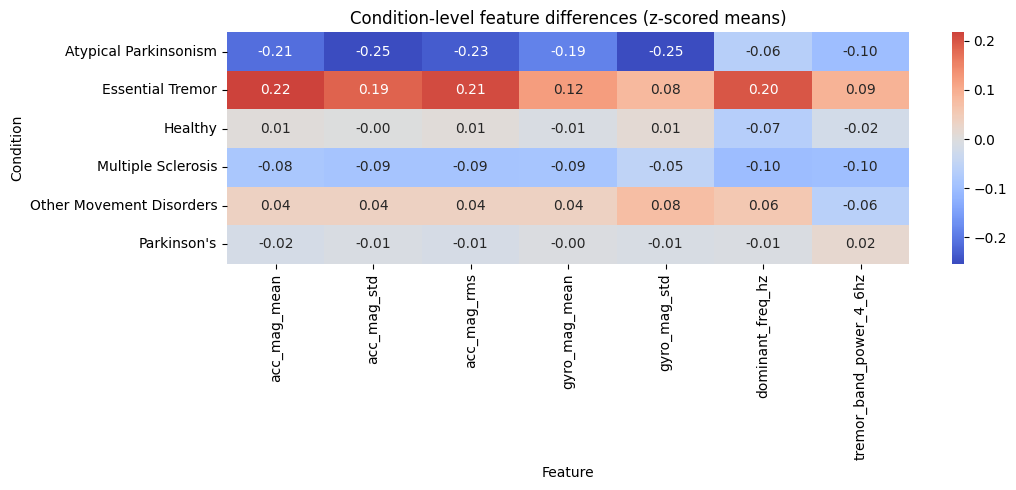


4) BOXPLOTS FOR TOP PD-vs-NON-PD FEATURES


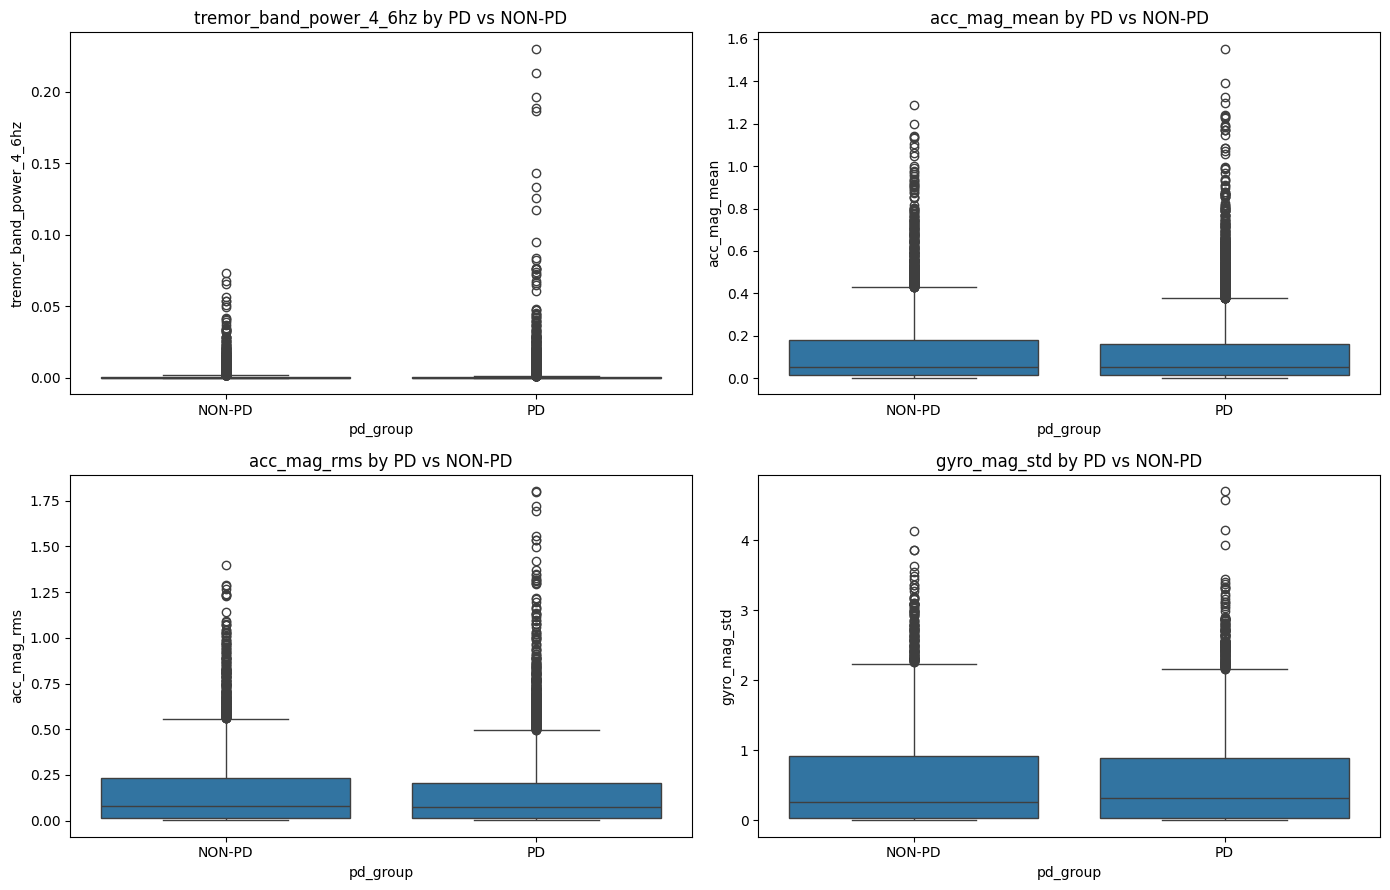


Note: t-test section is binary (PD vs NON-PD); heatmap remains multi-condition descriptive.


In [60]:
print('=' * 70)
print('EDA ON df_features (AGGREGATED BY CONDITION)')
print('=' * 70)

missing_total = int(df_features.isna().sum().sum())
missing_pct = (missing_total / (df_features.shape[0] * df_features.shape[1])) * 100
print(f'\nTotal missing values: {missing_total} ({missing_pct:.2f}% of all cells)')

# Features selected for condition-level comparison
key_cols = [
    'acc_mag_mean', 'acc_mag_std', 'acc_mag_rms',
    'gyro_mag_mean', 'gyro_mag_std',
    'dominant_freq_hz', 'tremor_band_power_4_6hz'
]

# ------------------------------------------------------------------
# 1) CONDITION-LEVEL DESCRIPTIVE STATISTICS
# ------------------------------------------------------------------
print('\n' + '=' * 70)
print('1) CONDITION-LEVEL DESCRIPTIVE STATS')
print('=' * 70)

condition_counts = df_features['condition'].value_counts().sort_values(ascending=False)
print('\nFiles per condition:')
print(condition_counts)

condition_mean = df_features.groupby('condition')[key_cols].mean()
condition_median = df_features.groupby('condition')[key_cols].median()
condition_std = df_features.groupby('condition')[key_cols].std()

print('\nMean by condition:')
print(condition_mean.round(4))

print('\nMedian by condition:')
print(condition_median.round(4))

print('\nStd by condition:')
print(condition_std.round(4))

# ------------------------------------------------------------------
# 2) BINARY WELCH T-TEST: PD vs NON-PD
# ------------------------------------------------------------------
print('\n' + '=' * 70)
print('2) BINARY WELCH T-TEST (PD vs NON-PD)')
print('=' * 70)

def _fdr_bh(p_values):
    p = np.asarray(p_values, dtype=float)
    adj = np.full_like(p, np.nan)
    valid_idx = np.where(~np.isnan(p))[0]
    if len(valid_idx) == 0:
        return adj

    p_valid = p[valid_idx]
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    m = len(ranked)

    q = ranked * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    adj_valid = np.empty_like(ranked)
    adj_valid[order] = q
    adj[valid_idx] = adj_valid
    return adj

# Define binary label: PD if condition is exactly Parkinson's/PD, else NON-PD
df_bin = df_features.copy()
df_bin['is_pd'] = df_bin['condition'].astype(str).str.strip().str.lower().isin([
    "parkinson's", 'parkinsons', 'parkinson', 'pd'
])

pd_count = int(df_bin['is_pd'].sum())
non_pd_count = int((~df_bin['is_pd']).sum())
print(f'PD rows: {pd_count}')
print(f'NON-PD rows: {non_pd_count}')

# Welch t-test with scipy if available
try:
    from scipy.stats import ttest_ind
    scipy_available = True
except Exception:
    scipy_available = False
    print('SciPy not available: t-test skipped. Install scipy to run this section.')

ttest_rows = []
if scipy_available:
    for feature in key_cols:
        pd_values = df_bin.loc[df_bin['is_pd'], feature].dropna().values
        non_pd_values = df_bin.loc[~df_bin['is_pd'], feature].dropna().values

        if len(pd_values) < 2 or len(non_pd_values) < 2:
            ttest_rows.append({
                'feature': feature,
                'n_pd': int(len(pd_values)),
                'n_non_pd': int(len(non_pd_values)),
                'mean_pd': np.nan,
                'mean_non_pd': np.nan,
                'mean_diff_pd_minus_non_pd': np.nan,
                't_stat': np.nan,
                'p_value': np.nan,
                'cohens_d': np.nan
            })
            continue

        t_stat, p_value = ttest_ind(pd_values, non_pd_values, equal_var=False)

        mean_pd = float(np.mean(pd_values))
        mean_non_pd = float(np.mean(non_pd_values))
        mean_diff = mean_pd - mean_non_pd

        var_pd = np.var(pd_values, ddof=1)
        var_non_pd = np.var(non_pd_values, ddof=1)
        pooled_sd = np.sqrt(((len(pd_values) - 1) * var_pd + (len(non_pd_values) - 1) * var_non_pd) /
                            (len(pd_values) + len(non_pd_values) - 2))
        cohens_d = mean_diff / pooled_sd if pooled_sd > 0 else np.nan

        ttest_rows.append({
            'feature': feature,
            'n_pd': int(len(pd_values)),
            'n_non_pd': int(len(non_pd_values)),
            'mean_pd': mean_pd,
            'mean_non_pd': mean_non_pd,
            'mean_diff_pd_minus_non_pd': float(mean_diff),
            't_stat': float(t_stat),
            'p_value': float(p_value),
            'cohens_d': float(cohens_d) if pd.notna(cohens_d) else np.nan
        })

    ttest_df = pd.DataFrame(ttest_rows)
    ttest_df['p_fdr_bh'] = _fdr_bh(ttest_df['p_value'].values)
    ttest_df['significant_0_05'] = ttest_df['p_value'] < 0.05
    ttest_df['significant_fdr_0_05'] = ttest_df['p_fdr_bh'] < 0.05
    ttest_df = ttest_df.sort_values('p_value', ascending=True)

    print('\nWelch t-test results (sorted by p-value):')
    print(ttest_df.round(6))

    sig_raw = int(ttest_df['significant_0_05'].sum())
    sig_fdr = int(ttest_df['significant_fdr_0_05'].sum())
    print(f'\nSignificant features (raw p < 0.05): {sig_raw}/{len(ttest_df)}')
    print(f'Significant features (FDR p < 0.05): {sig_fdr}/{len(ttest_df)}')

# ------------------------------------------------------------------
# 3) HEATMAP OF DIFFERENCES BETWEEN CONDITIONS
#    (z-scored condition means vs global mean)
# ------------------------------------------------------------------
print('\n' + '=' * 70)
print('3) HEATMAP: CONDITION DIFFERENCES (Z-SCORED MEANS)')
print('=' * 70)

global_mean = df_features[key_cols].mean()
global_std = df_features[key_cols].std().replace(0, np.nan)
condition_z = (condition_mean - global_mean) / global_std

plt.figure(figsize=(11, 5))
sns.heatmap(condition_z, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Condition-level feature differences (z-scored means)')
plt.xlabel('Feature')
plt.ylabel('Condition')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4) BOXPLOTS FOR TOP PD-vs-NON-PD FEATURES
# ------------------------------------------------------------------
print('\n' + '=' * 70)
print('4) BOXPLOTS FOR TOP PD-vs-NON-PD FEATURES')
print('=' * 70)

if scipy_available and 'ttest_df' in locals() and len(ttest_df) > 0:
    top_features = ttest_df['feature'].head(4).tolist()
else:
    top_features = key_cols[:4]

df_plot = df_features.copy()
df_plot['pd_group'] = np.where(
    df_plot['condition'].astype(str).str.strip().str.lower().isin(["parkinson's", 'parkinsons', 'parkinson', 'pd']),
    'PD',
    'NON-PD'
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(data=df_plot, x='pd_group', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature} by PD vs NON-PD')
    axes[i].tick_params(axis='x', rotation=0)

# Hide unused subplots if fewer than 4 features
for j in range(len(top_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print('\nNote: t-test section is binary (PD vs NON-PD); heatmap remains multi-condition descriptive.')

## 8.5 Outlier Analysis (IQR Method)

OUTLIER ANALYSIS — IQR METHOD (1.5×IQR fence)
                Feature  N outliers  % outliers
tremor_band_power_4_6hz        1685       16.33
            total_power        1203       11.66
       dominant_freq_hz        1066       10.33
           acc_mag_mean         874        8.47
          gyro_mag_mean         816        7.91
          acc_mag_range         724        7.02
            acc_mag_rms         705        6.83
           gyro_mag_rms         622        6.03
            acc_mag_std         446        4.32
           gyro_mag_std         313        3.03

Total files analysed: 10318


OUTLIER ANALYSIS — IQR METHOD (1.5×IQR fence)
                Feature  N outliers  % outliers
tremor_band_power_4_6hz        1685       16.33
            total_power        1203       11.66
       dominant_freq_hz        1066       10.33
           acc_mag_mean         874        8.47
          gyro_mag_mean         816        7.91
          acc_mag_range         724        7.02
            acc_mag_rms         705        6.83
           gyro_mag_rms         622        6.03
            acc_mag_std         446        4.32
           gyro_mag_std         313        3.03

Total files analysed: 10318


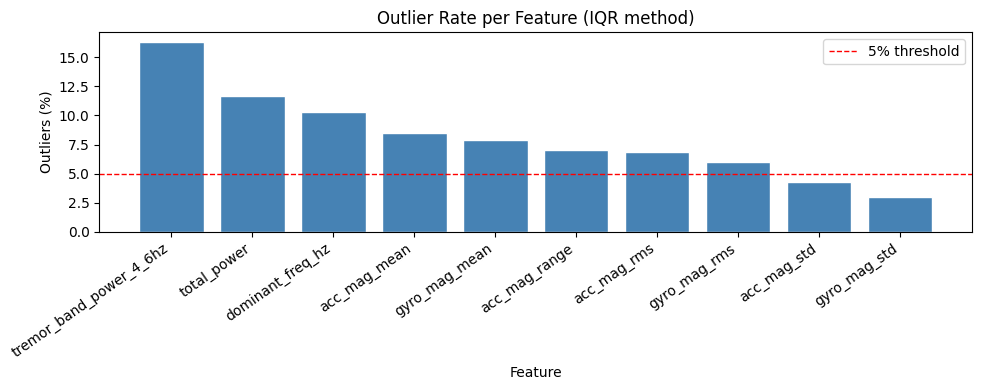

In [17]:
key_cols = [
    'acc_mag_mean', 'acc_mag_std', 'acc_mag_rms', 'acc_mag_range',
    'gyro_mag_mean', 'gyro_mag_std', 'gyro_mag_rms',
    'dominant_freq_hz', 'tremor_band_power_4_6hz', 'total_power'
]
key_cols = [c for c in key_cols if c in df_features.columns]

# IQR outlier count per feature
outlier_rows = []
for col in key_cols:
    Q1 = df_features[col].quantile(0.25)
    Q3 = df_features[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_features[col] < lower) | (df_features[col] > upper)).sum()
    pct_out = n_out / len(df_features) * 100
    outlier_rows.append({'Feature': col, 'N outliers': n_out, '% outliers': round(pct_out, 2)})

df_outliers = pd.DataFrame(outlier_rows).sort_values('% outliers', ascending=False)

print('=' * 55)
print('OUTLIER ANALYSIS — IQR METHOD (1.5×IQR fence)')
print('=' * 55)
print(df_outliers.to_string(index=False))
print(f'\nTotal files analysed: {len(df_features)}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_outliers['Feature'], df_outliers['% outliers'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature')
ax.set_ylabel('Outliers (%)')
ax.set_title('Outlier Rate per Feature (IQR method)')
ax.set_xticklabels(df_outliers['Feature'], rotation=35, ha='right')
ax.axhline(5, color='red', linestyle='--', linewidth=1, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()
